## Classical ML Model #1: **Binomial Logistic Regression**


First, we will import our pre-split and scaled training, validation, and test sets.

In [1]:
import pandas as pd
import numpy as np
import ast
import joblib

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

# **[4]** Model Selection Training

### **Training Set**: Binomial Logistic Regression

We are trying to predict if the our target class URB is rural or urban, 2 classes so a Binomial Logistic Regression is a natural pick. Let's first create our model using the the import from the sklearn library for our logistic Regression

In [2]:
# Logistic Regression (L2 Regularization) - Training Phase
from sklearn.linear_model import LogisticRegression

# Regularized logistic regression model
logreg_model = LogisticRegression(
    penalty="l2",       # regularization type (this is default)
    C=1.0,               # regularization strength (also a default)
    solver="lbfgs",     # optimizer (good default for larger datasets)
    max_iter=100,
    random_state=42
)

logreg_model.fit(X_train_scaled, y_train)

# Training-set predictions and probabilities
y_train_pred = logreg_model.predict(X_train_scaled)
y_train_proba = logreg_model.predict_proba(X_train_scaled)[:, 1]

With our training split, we currently have **28119** rows. We will use **44** features (including target) to predict target feature `URB` whether its rural or urban. Our output below shows 85 features, but why? We performed one-hot-encoding on 7 of our used features. `W_REGN`, `BLDG_TYPE`, `ROOF`, `WALLS`, `TOILET`, `ELECTRIC`, and `WATER`. Furthurmore, we remove the target column `URB`.

For example, `W_REGN` has 17 unique values because the dataset has 17 regions. We perfomed one-hot-encoding on features that has categorical values, which is why the number of our features increased.

In [3]:
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Training features used: {X_train_scaled.shape[1]}")

Training samples: 28119
Training features used: 85


Let's now output our metrics. It is important to note that our classes are imbalanced. The entire dataset contains 40171 total number of entries. There are 15373 urban families and 24798 rural families.

In [4]:
from MCO_functions import report_binary_metrics, build_metric_series, highlight_val_train_row, run_logreg_validation_grid

train_report = report_binary_metrics(
    y_true=y_train,
    y_pred=y_train_pred,
    y_proba=y_train_proba,
    title="Training Metrics",
    n_iter=logreg_model.n_iter_,
)

cm_train = train_report["cm"]
cm_train_df = train_report["cm_df"]

Training Metrics (Overall)
Accuracy        : 0.8247
Balanced Acc    : 0.8011
ROC-AUC         : 0.8887
PR-AUC          : 0.8621
Log Loss        : 0.3913

Per-Class Metrics


,Rural (0),Urban (1)
Precision,0.8293,0.8152
Recall,0.9015,0.7008
F1-score,0.8639,0.7536



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)           15648            1710
Actual Urban (1)            3220            7541

Iterations used: [86]


In simple terms, the training results are good overall.

Out of all **actual rural** households, the model correctly predicted **15,648** as rural, while **1,710** were incorrectly predicted as urban.
Out of all **actual urban** households, the model correctly predicted **7,541** as urban, while **3,220** were incorrectly predicted as rural.

This means the model is generally strong, but it still makes more mistakes on urban households than on rural households.

The line `Iterations used: [86]` means the logistic regression optimizer needed **86 epochs or iterations** to converge during training.

Now let's visualize how the model improved by visualizing the loss per epoch or iteration

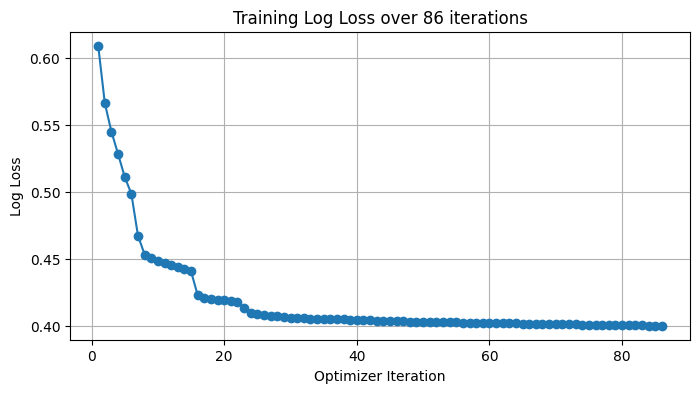

Showing first 10 and last 10 iterations out of 86 total:


,Optimizer Iteration,Train Log Loss
0,1,0.609409
1,2,0.566374
2,3,0.545036
3,4,0.528377
4,5,0.511299
5,6,0.498686
6,7,0.467351
7,8,0.453335
8,9,0.450536
9,10,0.448557


In [5]:
# Optional: inspect training loss over all optimizer iterations (reusable helper)
from MCO_functions import track_logreg_loss_by_iteration

# Track the same number of iterations used by the fitted training model
total_iters = int(np.ravel(logreg_model.n_iter_)[0])

loss_tracking = track_logreg_loss_by_iteration(
    X_train=X_train_scaled,
    y_train=y_train,
    total_iterations=total_iters,
    c=1.0,
    penalty="l2",
    solver="lbfgs",
    class_weight=None,
    random_state=42,
    head_n=10,
    tail_n=10,
    plot=True,
)

loss_history_df = loss_tracking["full_loss_df"]
loss_window_df = loss_tracking["compact_loss_df"]

print(f"Showing first 10 and last 10 iterations out of {total_iters} total:")
display(loss_window_df.style.format({"Train Log Loss": "{:.6f}"}))

The loss trend shows that the model learned quickly in the early iterations, then improved more slowly as training continued.

At iteration **1**, train log loss is **0.609409**.
By iteration **10**, it drops to **0.448557** (large early improvement).
From iterations **77 to 86**, loss only changes slightly from **0.400677** to **0.400092**, which means the model is already close to convergence.

In short, most learning happened early, and later iterations gave smaller fine-tuning gains.

# **[5]** Error Analysis and Model Tuning


### **Validation Set** (Pre-Tuned): Binomial Logistic Regression

Using our trained model, let's test it on the validation set. The validation set has **6026** rows of data

We do this so we can see if the model is biased toward the training set by testing it on the validation set. Then we can make adjustments later when tuning our model

In [6]:
from MCO_functions import report_binary_metrics

# BEFORE TUNING: baseline validation metrics
y_val_pred = logreg_model.predict(X_val_scaled)
y_val_proba = logreg_model.predict_proba(X_val_scaled)[:, 1]

val_base_report = report_binary_metrics(
    y_true=y_val,
    y_pred=y_val_pred,
    y_proba=y_val_proba,
    title="Current Validation Metrics (Before Tuning)",
)

cm_base = val_base_report["cm"]
cm_base_df = val_base_report["cm_df"]

Current Validation Metrics (Before Tuning) (Overall)
Accuracy        : 0.8123
Balanced Acc    : 0.7910
ROC-AUC         : 0.8783
PR-AUC          : 0.8488
Log Loss        : 0.4085

Per-Class Metrics


,Rural (0),Urban (1)
Precision,0.8258,0.7862
Recall,0.8820,0.6999
F1-score,0.8530,0.7405



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3281             439
Actual Urban (1)             692            1614


Let's compare the pre-tuned model's performance with the training and validation set.

In [7]:
# Training vs Pre-Tuned Validation comparison with color highlights
metric_order = [
    "Accuracy", "Balanced Acc",
    "Rural Precision", "Rural Recall", "Rural F1",
    "Urban Precision", "Urban Recall", "Urban F1",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Precision": "higher",
    "Rural Recall": "higher",
    "Rural F1": "higher",
    "Urban Precision": "higher",
    "Urban Recall": "higher",
    "Urban F1": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

comparison_df = pd.concat(
    [
        build_metric_series(y_train, y_train_pred, y_train_proba, cm_train, metric_order).rename("Training"),
        build_metric_series(y_val, y_val_pred, y_val_proba, cm_base, metric_order).rename("Pre-Tuned Validation"),
    ],
    axis=1,
)
comparison_df["Val - Train"] = comparison_df["Pre-Tuned Validation"] - comparison_df["Training"]

styled_comparison = (
    comparison_df.style
    .format(
        {
            "Training": "{:.4f}",
            "Pre-Tuned Validation": "{:.4f}",
            "Val - Train": "{:+.4f}",
        }
    )
    .apply(lambda row: highlight_val_train_row(row, direction_map, delta_col="Val - Train"), axis=1)
    .set_caption(
        "Training vs Pre-Tuned Validation Metrics "
        "(Val - Train color: green = better on validation given metric direction, red = worse, yellow = tie)"
    )
)

#### **Pre-tuned Model**: Validation set vs Training set Performance

In [8]:
print("Training vs Pre-Tuned Validation")
print("Legend: Green = improved on validation, Red = dropped on validation, Yellow = no change")
display(styled_comparison)

Training vs Pre-Tuned Validation
Legend: Green = improved on validation, Red = dropped on validation, Yellow = no change


,Training,Pre-Tuned Validation,Val - Train
Accuracy,0.8247,0.8123,-0.0124
Balanced Acc,0.8011,0.7910,-0.0102
Rural Precision,0.8293,0.8258,-0.0035
Rural Recall,0.9015,0.8820,-0.0195
Rural F1,0.8639,0.8530,-0.0109
Urban Precision,0.8152,0.7862,-0.0290
Urban Recall,0.7008,0.6999,-0.0009
Urban F1,0.7536,0.7405,-0.0131
ROC-AUC,0.8887,0.8783,-0.0105
PR-AUC,0.8621,0.8488,-0.0133


This comparison table checks how well the model generalizes from training data to unseen validation data.

**Green** means validation improved versus training for that metric.
**Red** means validation dropped versus training for that metric.
**Yellow** (pretty unlikely) means there was little to no change.

A small drop on validation is normal because the model was fit on training data. The key is that the drops are not too large, which suggests the baseline model is learning useful patterns and can still be improved further through tuning.

With that in mind, let's **fine-tune** our model

### **Validation Set** (Tuned): Binomial Logistic Regression 

We will create a list of values per hyperparameters located in `run_logreg_validation_grid` function. The function iterates through the possible combinations/configurations of hyperparameters and chooses the best set of hyperparameters

In [9]:
# Fine tuning our model with validation set
candidate_df = run_logreg_validation_grid(X_train_scaled, y_train, X_val_scaled, y_val)

print("\nValidation Tuning Results (top 5):")
display(candidate_df.head(5))

best = candidate_df.iloc[0]
best_c = float(best["C"])
best_solver = str(best["Solver"])
best_threshold = float(best["Threshold"])

if best["Class_Weight"] == "None":
    best_class_weight = None
elif best["Class_Weight"] == "balanced":
    best_class_weight = "balanced"
else:
    best_class_weight = ast.literal_eval(best["Class_Weight"])

print("\nBest validation configuration (Balanced):")
print(f"C            : {best_c}")
print(f"Solver       : {best_solver}")
print(f"Class Weight : {best_class_weight}")
print(f"Threshold    : {best_threshold}")

# Fit tuned model selected from validation ranking
logreg_model_tuned = LogisticRegression(
    penalty="l2",
    C=best_c,
    solver=best_solver,
    class_weight=best_class_weight,
    max_iter=1000,
    random_state=42
)
logreg_model_tuned.fit(X_train_scaled, y_train)

y_val_proba_tuned = logreg_model_tuned.predict_proba(X_val_scaled)[:, 1]
y_val_pred_tuned = (y_val_proba_tuned >= best_threshold).astype(int)


Validation Tuning Results (top 5):


,C,Solver,Class_Weight,Threshold,Accuracy,Balanced_Acc,Rural_Acc,Urban_Acc,Rural_Precision,Rural_Recall,Rural_F1,Urban_Precision,Urban_Recall,Urban_F1,ROC_AUC,PR_AUC,LogLoss
0,3.0,lbfgs,"{0: 1.15, 1: 1.0}",0.34,0.801527,0.797956,0.813172,0.782741,0.857913,0.813172,0.834943,0.722000,0.782741,0.751144,0.878181,0.848940,0.409221
1,3.0,lbfgs,"{0: 1.1, 1: 1.0}",0.35,0.801527,0.797874,0.813441,0.782307,0.857710,0.813441,0.834989,0.722178,0.782307,0.751041,0.878214,0.848901,0.408741
2,30.0,liblinear,balanced,0.48,0.800365,0.797840,0.808602,0.787077,0.859674,0.808602,0.833356,0.718243,0.787077,0.751086,0.878377,0.848348,0.425282
3,10.0,lbfgs,balanced,0.48,0.800199,0.797788,0.808065,0.787511,0.859840,0.808065,0.833149,0.717787,0.787511,0.751034,0.878382,0.848289,0.425310
4,3.0,lbfgs,balanced,0.48,0.800199,0.797705,0.808333,0.787077,0.859634,0.808333,0.833195,0.717959,0.787077,0.750931,0.878445,0.848333,0.425271



Best validation configuration (Balanced):
C            : 3.0
Solver       : lbfgs
Class Weight : {0: 1.15, 1: 1.0}
Threshold    : 0.34


The first table (**top 5**) shows the best hyperparameter combinations ranked by validation performance (especially Balanced Accuracy).

The **best configuration** is the single combination selected for the final tuned logistic regression model.

After choosing that best setup, the model is re-trained on the training set, then used to produce validation probabilities and validation class predictions using the tuned threshold.

This step automatically tests many combinations and keeps the one that gives the strongest validation performance for our imbalanced classes.

Here is a simple meaning of the tuned hyperparameters shown above:

- **C** controls regularization strength. Smaller C means stronger regularization (simpler model), larger C means weaker regularization (more flexible model).
- **Solver** is the optimization algorithm used to fit logistic regression (for example, `lbfgs` or `liblinear`).
- **Class weight** tells the model how much importance to give each class, which helps with class imbalance.
- **Decision threshold** is the probability cutoff for predicting Urban (1). Lowering it usually predicts Urban more often; raising it predicts Rural more often.

In short, tuning these values helps balance overall performance and fairness between Rural and Urban predictions.

In [10]:
from MCO_functions import report_binary_metrics

val_tuned_report = report_binary_metrics(
    y_true=y_val,
    y_pred=y_val_pred_tuned,
    y_proba=y_val_proba_tuned,
    title="Tuned Model Validation Metrics",
    threshold=best_threshold,
    n_iter=logreg_model_tuned.n_iter_,
)

cm_tuned = val_tuned_report["cm"]
cm_tuned_df = val_tuned_report["cm_df"]

Tuned Model Validation Metrics (Overall)
Threshold used  : 0.34
Accuracy        : 0.8015
Balanced Acc    : 0.7980
ROC-AUC         : 0.8782
PR-AUC          : 0.8489
Log Loss        : 0.4092

Per-Class Metrics


,Rural (0),Urban (1)
Precision,0.8579,0.7220
Recall,0.8132,0.7827
F1-score,0.8349,0.7511



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3025             695
Actual Urban (1)             501            1805

Iterations used: [93]


The above are the metrics for the performance of the **tuned** model for the validation set.

Now let's check if the model's performance post-tuning improved againts pre-tuning

In [12]:
# Pre-tuned vs Post-tuned validation comparison (same style as earlier comparison table)
metric_order_tuning = [
    "Accuracy", "Balanced Acc",
    "Rural Precision", "Rural Recall", "Rural F1",
    "Urban Precision", "Urban Recall", "Urban F1",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map_tuning = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Precision": "higher",
    "Rural Recall": "higher",
    "Rural F1": "higher",
    "Urban Precision": "higher",
    "Urban Recall": "higher",
    "Urban F1": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

tuned_comparison_df = pd.concat(
    [
        build_metric_series(y_val, y_val_pred, y_val_proba, cm_base, metric_order_tuning).rename("Pre-Tuned Validation"),
        build_metric_series(y_val, y_val_pred_tuned, y_val_proba_tuned, cm_tuned, metric_order_tuning).rename("Post-Tuned Validation"),
    ],
    axis=1,
)
tuned_comparison_df["Post - Pre"] = (
    tuned_comparison_df["Post-Tuned Validation"] - tuned_comparison_df["Pre-Tuned Validation"]
)

styled_tuned_comparison = (
    tuned_comparison_df.style
    .format(
        {
            "Pre-Tuned Validation": "{:.4f}",
            "Post-Tuned Validation": "{:.4f}",
            "Post - Pre": "{:+.4f}",
        }
    )
    .apply(
        lambda row: highlight_val_train_row(row, direction_map_tuning, delta_col="Post - Pre"),
        axis=1,
    )
    .set_caption(
        "Pre-Tuned vs Post-Tuned Validation Metrics "
        "(Post - Pre color: green = improved after tuning given metric direction, red = worse, yellow = tie)"
    )
)

print("Pre-Tuned vs Post-Tuned Validation")
print("Legend: Green = improved after tuning, Red = dropped after tuning, Yellow = no change")
display(styled_tuned_comparison)

Pre-Tuned vs Post-Tuned Validation
Legend: Green = improved after tuning, Red = dropped after tuning, Yellow = no change


,Pre-Tuned Validation,Post-Tuned Validation,Post - Pre
Accuracy,0.8123,0.8015,-0.0108
Balanced Acc,0.7910,0.7980,+0.0070
Rural Precision,0.8258,0.8579,+0.0321
Rural Recall,0.8820,0.8132,-0.0688
Rural F1,0.8530,0.8349,-0.0180
Urban Precision,0.7862,0.7220,-0.0642
Urban Recall,0.6999,0.7827,+0.0828
Urban F1,0.7405,0.7511,+0.0106
ROC-AUC,0.8783,0.8782,-0.0001
PR-AUC,0.8488,0.8489,+0.0002


We base our decision of the best (highest value) `balanced accuracy` because of our high class imbalance, **38% Urban** and **61% Rural**.

In this case, Post-tuned model definitely improved even if its by a little.

# **[6]** Model Evaluation


### **Test Set**: Binomial Logistic Regression

The test split also contains **6026** entries of data.

Let's now test our tuned model with the test set.

In [13]:
from MCO_functions import report_binary_metrics

# Final Test-Set Evaluation (locked model from validation tuning)
# Use tuned model and tuned decision threshold selected on validation set
y_test_proba = logreg_model_tuned.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

test_report = report_binary_metrics(
    y_true=y_test,
    y_pred=y_test_pred,
    y_proba=y_test_proba,
    title="Final Test Metrics",
    threshold=best_threshold,
)

cm_test = test_report["cm"]
cm_test_df = test_report["cm_df"]

Final Test Metrics (Overall)
Threshold used  : 0.34
Accuracy        : 0.8062
Balanced Acc    : 0.8012
ROC-AUC         : 0.8845
PR-AUC          : 0.8560
Log Loss        : 0.3994

Per-Class Metrics


,Rural (0),Urban (1)
Precision,0.8578,0.7313
Recall,0.8223,0.7801
F1-score,0.8397,0.7549



Confusion Matrix:
                  Pred Rural (0)  Pred Urban (1)
Actual Rural (0)            3059             661
Actual Urban (1)             507            1799


The above are the metrics of the **tuned** model's performance on the test set.

Now let's compare the model's performance on the test and post-tuning validation sets

In [14]:
# Post-tuned validation vs Test-set comparison (same style as earlier comparison table)
metric_order_test = [
    "Accuracy", "Balanced Acc",
    "Rural Precision", "Rural Recall", "Rural F1",
    "Urban Precision", "Urban Recall", "Urban F1",
    "ROC-AUC", "PR-AUC", "Log Loss",
]

# Higher is better for all except Log Loss.
direction_map_test = {
    "Accuracy": "higher",
    "Balanced Acc": "higher",
    "Rural Precision": "higher",
    "Rural Recall": "higher",
    "Rural F1": "higher",
    "Urban Precision": "higher",
    "Urban Recall": "higher",
    "Urban F1": "higher",
    "ROC-AUC": "higher",
    "PR-AUC": "higher",
    "Log Loss": "lower",
}

test_comparison_df = pd.concat(
    [
        build_metric_series(y_val, y_val_pred_tuned, y_val_proba_tuned, cm_tuned, metric_order_test).rename("Post-Tuned Validation"),
        build_metric_series(y_test, y_test_pred, y_test_proba, cm_test, metric_order_test).rename("Test Set"),
    ],
    axis=1,
)
test_comparison_df["Test - Post"] = (
    test_comparison_df["Test Set"] - test_comparison_df["Post-Tuned Validation"]
)

styled_test_comparison = (
    test_comparison_df.style
    .format(
        {
            "Post-Tuned Validation": "{:.4f}",
            "Test Set": "{:.4f}",
            "Test - Post": "{:+.4f}",
        }
    )
    .apply(
        lambda row: highlight_val_train_row(row, direction_map_test, delta_col="Test - Post"),
        axis=1,
    )
    .set_caption(
        "Post-Tuned Validation vs Test-Set Metrics "
        "(Test - Post color: green = improved on test given metric direction, red = worse, yellow = tie)"
    )
)

print("Post-Tuned Validation vs Test Set")
print("Legend: Green = improved on test set, Red = dropped on test set, Yellow = no change")
display(styled_test_comparison)

Post-Tuned Validation vs Test Set
Legend: Green = improved on test set, Red = dropped on test set, Yellow = no change


,Post-Tuned Validation,Test Set,Test - Post
Accuracy,0.8015,0.8062,+0.0046
Balanced Acc,0.7980,0.8012,+0.0033
Rural Precision,0.8579,0.8578,-0.0001
Rural Recall,0.8132,0.8223,+0.0091
Rural F1,0.8349,0.8397,+0.0047
Urban Precision,0.7220,0.7313,+0.0093
Urban Recall,0.7827,0.7801,-0.0026
Urban F1,0.7511,0.7549,+0.0038
ROC-AUC,0.8782,0.8845,+0.0063
PR-AUC,0.8489,0.8560,+0.0070


This table shows that the tuned model generalizes well from validation to test data, with **small overall improvements** on the test set.

- Overall performance improved slightly: **Accuracy** (+0.0046) and **Balanced Accuracy** (+0.0033).
- Ranking quality also improved: **ROC-AUC** (+0.0063) and **PR-AUC** (+0.0070).
- Error confidence improved because **Log Loss decreased** by 0.0098 (lower is better).
- Rural class performance is slightly better overall (higher recall and F1).
- Urban class results are mixed but stable: **Precision** improved (+0.0093), while **Recall** dipped slightly (-0.0026), and **F1** still improved (+0.0038).

In short, the tuned model kept its validation performance and performed a bit better on the test set, which suggests good generalization and no major overfitting.

In [15]:
import os

os.makedirs('model_outputs', exist_ok=True)

# Save the final locked-in tuned model
joblib.dump(logreg_model_tuned, 'model_outputs/logistic_regression_final_model.pkl')
joblib.dump(best_threshold, 'model_outputs/logistic_regression_threshold.pkl')

# Create a DataFrame of the test-set predictions and probabilities
lg_test_results = pd.DataFrame({
    'Actual_y_test': y_test,
    'LG_Predicted_Class': y_test_pred,
    'LG_Predicted_Probability': logreg_model_tuned.predict_proba(X_test_scaled)[:, 1],
})

# Export to CSV for easy comparison in the main directory
lg_test_results.to_csv('model_outputs/lg_test_predictions.csv', index=False)